# K-Nearest Neighbors (KNN) Algorithm
### Reference: [GeeksForGeeks - K-Nearest Neighbours](https://www.geeksforgeeks.org/k-nearest-neighbours/)

---

## Table of Contents
1. [Definition](#1-definition)
2. [How It Works](#2-how-it-works)
3. [Math Behind KNN — Distance Formulas](#3-math-behind-knn)
4. [Choosing the Value of K](#4-choosing-k)
5. [Step-by-Step Worked Example](#5-worked-example)
6. [Advantages & Disadvantages](#6-advantages--disadvantages)
7. [Applications](#7-applications)
8. [From-Scratch Implementation](#8-from-scratch-implementation)
9. [Scikit-Learn Implementation](#9-scikit-learn-implementation)
10. [Visualizing Decision Boundaries](#10-decision-boundaries)
11. [KNN for Regression](#11-knn-for-regression)
12. [Summary](#12-summary)

---
## 1. Definition

**K-Nearest Neighbors (KNN)** is a simple, **non-parametric**, supervised machine learning algorithm applicable to both **classification** and **regression** tasks.
when data points distributed in a non linear manner , we use this KNN.

It is called a **lazy learner** (or instance-based learner) because:
- It does **not build an explicit model** during training
- It **memorizes the entire training dataset**
- All computation is deferred to **prediction time**

### Core Idea
> *"Tell me who your neighbors are, and I'll tell you who you are."*

To classify a new data point, KNN:
1. Finds the **K training examples** closest to it (by distance)
2. Makes a decision based on those **K neighbors**

### Key Characteristics

| Property | Value |
|---|---|
| Learning Type | Supervised |
| Task | Classification + Regression |
| Model Type | Non-parametric, Instance-based |
| Learning Style | Lazy (no training phase) |
| Key Hyperparameter | K (number of neighbors) |

---
## 2. How It Works

```
Step 1: Choose K (number of neighbors)
Step 2: Compute distance from test point to ALL training points
Step 3: Sort distances; pick the K smallest
Step 4a (Classification): Majority vote among K neighbor labels
Step 4b (Regression):     Average of K neighbor target values
Step 5: Return prediction
```

### For Classification
The **most common class** among K neighbors is the prediction.

Example: K=5, neighbors = [A, A, B, A, B] → Prediction = **A** (3 votes)

### For Regression
The **average value** of K neighbors' target values is the prediction.

Example: K=3, neighbor values = [10, 14, 13] → Prediction = **(10+14+13)/3 = 12.33**

---
## 3. Math Behind KNN — Distance Formulas

The entire algorithm revolves around **measuring similarity** via distance.  
The **closer** two points are → the **more similar** they are.

---

### 3.1 Euclidean Distance (Most Common)
Straight-line distance in n-dimensional space:

$$d(x, x_i) = \sqrt{\sum_{j=1}^{n}(x_j - x_{ij})^2}$$

For 2D: $d(A, B) = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$

**Example:** A=(1,2), B=(4,6)
$$d = \sqrt{(4-1)^2 + (6-2)^2} = \sqrt{9+16} = \sqrt{25} = 5$$

---

### 3.2 Manhattan Distance (Taxicab / City Block)
Sum of absolute differences — models movement on a grid:

$$d(x, y) = \sum_{i=1}^{n}|x_i - y_i|$$

**Example:** A=(1,2), B=(4,6) → d = |4-1| + |6-2| = 3 + 4 = **7**

---

### 3.3 Minkowski Distance (Generalized)
Unifies both Euclidean and Manhattan via parameter **p**:

$$d(x, y) = \left(\sum_{i=1}^{n}|x_i - y_i|^p\right)^{\frac{1}{p}}$$

| p value | Equivalent to |
|---|---|
| p = 1 | Manhattan Distance |
| p = 2 | Euclidean Distance |
| p → ∞ | Chebyshev Distance (max of differences) |

---

### Distance Comparison Summary

| Distance | Formula | Best For |
|---|---|---|
| Euclidean | √Σ(xᵢ−yᵢ)² | Continuous features, standard use |
| Manhattan | Σ|xᵢ−yᵢ| | Grid-like data, outlier-robust |
| Minkowski | (Σ|xᵢ−yᵢ|ᵖ)^(1/p) | Generalized, tunable |
| Hamming | Count of mismatches | Binary/categorical features |

In [1]:
import numpy as np
from scipy.spatial.distance import euclidean, cityblock, minkowski

A = np.array([1, 2])
B = np.array([4, 6])

print("=== Distance Calculations: A=(1,2)  B=(4,6) ===")

euc  = np.sqrt(np.sum((A - B)**2))
man  = np.sum(np.abs(A - B))
mink = np.sum(np.abs(A - B)**3)**(1/3)
cheb = np.max(np.abs(A - B))

print(f"Euclidean  : sqrt((4-1)² + (6-2)²) = sqrt(9+16) = {euc}")
print(f"Manhattan  : |4-1| + |6-2| = 3 + 4 = {man}")
print(f"Minkowski(p=3): (|3|³ + |4|³)^(1/3) = {mink:.4f}")
print(f"Chebyshev  : max(|4-1|, |6-2|) = max(3,4) = {cheb}")

print("\n--- scipy verification ---")
print(f"Euclidean (scipy) : {euclidean(A, B)}")
print(f"Manhattan (scipy) : {cityblock(A, B)}")
print(f"Minkowski(p=3) scipy: {minkowski(A, B, p=3):.4f}")

=== Distance Calculations: A=(1,2)  B=(4,6) ===
Euclidean  : sqrt((4-1)² + (6-2)²) = sqrt(9+16) = 5.0
Manhattan  : |4-1| + |6-2| = 3 + 4 = 7
Minkowski(p=3): (|3|³ + |4|³)^(1/3) = 4.4979
Chebyshev  : max(|4-1|, |6-2|) = max(3,4) = 4

--- scipy verification ---
Euclidean (scipy) : 5.0
Manhattan (scipy) : 7
Minkowski(p=3) scipy: 4.4979


---
## 4. Choosing the Value of K

K is the **most critical hyperparameter** in KNN. It controls the bias-variance tradeoff:

```
Small K (K=1)              ←──────→              Large K (K=n)
   Overfits                                          Underfits
   High Variance                                     High Bias
   Noisy/complex boundaries                     Smooth boundaries
   Memorizes training noise              Ignores local patterns
```

### Strategies to Find Optimal K

| Strategy | Description |
|---|---|
| **Cross-Validation** | Test K values with k-fold CV; pick best accuracy |
| **Elbow Method** | Plot error rate vs K; pick the inflection point |
| **Rule of Thumb** | Start with K = √n (n = number of training samples) |
| **Use Odd K** | Always odd in binary classification to avoid ties |

### Practical Tips
- Test K from **1 to 20** with 5-fold cross-validation
- For **imbalanced datasets**: use `weights='distance'`
- **Always normalize features** before KNN — this is not optional!

---
## 5. Step-by-Step Worked Example

**Problem:** Classify test point **[4, 5]** as class **A** or **B** using K=3.

**Training Data:**

| Point | Features | Label |
|---|---|---|
| P1 | (1, 2) | A |
| P2 | (2, 3) | A |
| P3 | (3, 4) | A |
| P4 | (6, 7) | B |
| P5 | (7, 8) | B |

**Step 1:** Choose K = 3

**Step 2:** Compute Euclidean distances from **(4, 5)**:

$$d(P1) = \sqrt{(4-1)^2+(5-2)^2} = \sqrt{18} \approx 4.24$$
$$d(P2) = \sqrt{(4-2)^2+(5-3)^2} = \sqrt{8}  \approx 2.83$$
$$d(P3) = \sqrt{(4-3)^2+(5-4)^2} = \sqrt{2}  \approx 1.41  \leftarrow \text{nearest}$$
$$d(P4) = \sqrt{(4-6)^2+(5-7)^2} = \sqrt{8}  \approx 2.83$$
$$d(P5) = \sqrt{(4-7)^2+(5-8)^2} = \sqrt{18} \approx 4.24$$

**Step 3:** 3 Nearest = P3(A), P2(A), P4(B)

**Step 4:** Votes → A=2, B=1  

**✅ Prediction: Class A**

=== KNN Worked Example ===
Test point: [4. 5.]  K=3

d([4,5], [1, 2]) = sqrt(18) = 4.2426  | Label: A
d([4,5], [2, 3]) = sqrt(8) = 2.8284  | Label: A
d([4,5], [3, 4]) = sqrt(2) = 1.4142  | Label: A
d([4,5], [6, 7]) = sqrt(8) = 2.8284  | Label: B
d([4,5], [7, 8]) = sqrt(18) = 4.2426  | Label: B

--- 3 Nearest Neighbors ---
  Rank 1: Point [3, 4]  dist=1.4142  label=A
  Rank 2: Point [2, 3]  dist=2.8284  label=A
  Rank 3: Point [6, 7]  dist=2.8284  label=B

Votes: {'A': 2, 'B': 1}  →  Prediction: Class A


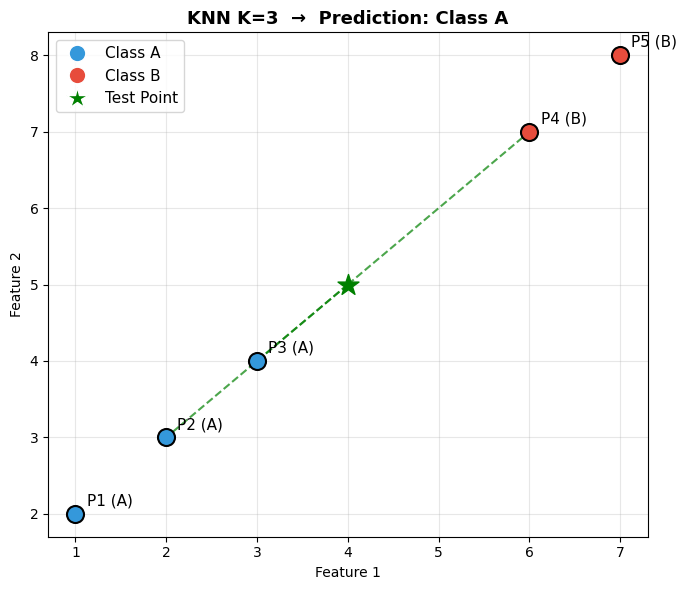

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

training_data   = np.array([[1,2],[2,3],[3,4],[6,7],[7,8]], dtype=float)
training_labels = np.array(['A','A','A','B','B'])
test_point      = np.array([4, 5], dtype=float)
K = 3

print("=== KNN Worked Example ===")
print(f"Test point: {test_point}  K={K}\n")

distances = []
for i, pt in enumerate(training_data):
    dist = np.sqrt(np.sum((test_point - pt)**2))
    sq   = int(np.sum((test_point - pt)**2))
    distances.append((dist, training_labels[i], pt))
    print(f"d([4,5], {list(pt.astype(int))}) = sqrt({sq}) = {dist:.4f}  | Label: {training_labels[i]}")

distances.sort(key=lambda x: x[0])
k_nearest = distances[:K]

print(f"\n--- {K} Nearest Neighbors ---")
for rank, (dist, label, pt) in enumerate(k_nearest, 1):
    print(f"  Rank {rank}: Point {list(pt.astype(int))}  dist={dist:.4f}  label={label}")

votes      = Counter([lbl for _, lbl, _ in k_nearest])
prediction = votes.most_common(1)[0][0]
print(f"\nVotes: {dict(votes)}  →  Prediction: Class {prediction}")

# Visualization
fig, ax = plt.subplots(figsize=(7, 6))
colors = {'A': '#3498db', 'B': '#e74c3c'}
for i, (pt, label) in enumerate(zip(training_data, training_labels)):
    ax.scatter(*pt, color=colors[label], s=150, zorder=5,
               edgecolors='black', linewidths=1.5)
    ax.annotate(f'P{i+1} ({label})', pt,
                textcoords='offset points', xytext=(8,6), fontsize=11)

ax.scatter(*test_point, color='green', s=250, marker='*', zorder=10, label='Test [4,5]')
for _, label, pt in k_nearest:
    ax.plot([test_point[0], pt[0]], [test_point[1], pt[1]], 'g--', alpha=0.7, linewidth=1.5)

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Class A'),
          Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=12, label='Class B'),
          Line2D([0],[0], marker='*', color='w', markerfacecolor='green',   markersize=16, label='Test Point')]
ax.legend(handles=legend, fontsize=11)
ax.set_title(f'KNN K={K}  →  Prediction: Class {prediction}', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Advantages & Disadvantages

### ✅ Advantages

| Advantage | Explanation |
|---|---|
| Simple & Intuitive | Easy to understand, explain, and implement |
| No Training Phase | Instantly adapts — just add new data to training set |
| No Assumptions | Non-parametric, works on any decision boundary shape |
| Versatile | Works for classification AND regression |
| Multi-class Ready | Handles multi-class problems without modification |
| Minimal Hyperparameters | Only K and distance metric need selection |

### ❌ Disadvantages

| Disadvantage | Explanation |
|---|---|
| Slow Predictions | Computes distances to ALL training points → O(n·d) per query |
| High Memory Usage | Must store entire training dataset in memory |
| Curse of Dimensionality | In high-d spaces, all points become equidistant |
| Feature Scale Sensitive | Large-scale features dominate — **StandardScaler is mandatory** |
| Irrelevant Feature Sensitive | Noisy/irrelevant features distort distance calculations |
| Overfits at K=1 | Memorizes training data completely |
| Imbalanced Data Issues | Majority class dominates voting |

---
## 7. Applications

| Domain | Application |
|---|---|
| E-commerce | Recommendation systems (find similar users/items) |
| Email | Spam detection (classify based on similar known emails) |
| Finance | Credit scoring, fraud detection |
| Healthcare | Disease diagnosis (classify based on patient feature similarity) |
| Computer Vision | Image classification, face recognition |
| NLP | Text classification, document similarity |
| Anomaly Detection | Points far from all neighbors are likely anomalies |

---
## 8. From-Scratch Implementation

In [8]:
import numpy as np
from collections import Counter

class KNNClassifier:
    """K-Nearest Neighbors Classifier — from scratch."""

    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def _distance(self, a, b):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((a - b)**2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.metric == 'minkowski':
            p = 3
            return np.sum(np.abs(a - b)**p)**(1/p)
        raise ValueError(f"Unknown metric: {self.metric}")

    def _predict_one(self, x):
        dists    = [self._distance(x, xt) for xt in self.X_train]
        k_idx    = np.argsort(dists)[:self.k]
        k_labels = self.y_train[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._predict_one(x) for x in np.array(X, dtype=float)])

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))


# Test on worked example
X_train = [[1,2],[2,3],[3,4],[6,7],[7,8]]
y_train = ['A','A','A','B','B']

knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)

print("Prediction for [4,5]:", knn.predict([[4,5]])[0])   # Expected: A

test_pts = [[1,1], [5,5], [8,8]]
preds    = knn.predict(test_pts)
for pt, pred in zip(test_pts, preds):
    print(f"  Point {pt} → Class {pred}")

print("\n--- Distance Metric Comparison ---")
for metric in ['euclidean', 'manhattan', 'minkowski']:
    knn_m = KNNClassifier(k=3, metric=metric).fit(X_train, y_train)
    pred  = knn_m.predict([[4,5]])[0]
    print(f"  metric={metric:12s} → Prediction: {pred}")

Prediction for [4,5]: A
  Point [1, 1] → Class A
  Point [5, 5] → Class A
  Point [8, 8] → Class B

--- Distance Metric Comparison ---
  metric=euclidean    → Prediction: A
  metric=manhattan    → Prediction: A
  metric=minkowski    → Prediction: A


---
## 9. Scikit-Learn Implementation

Dataset: 500 samples, 2 features
Classes: [0 1]  Distribution: {0: 250, 1: 250}

Optimal K = 21  |  Best CV Accuracy = 0.9200


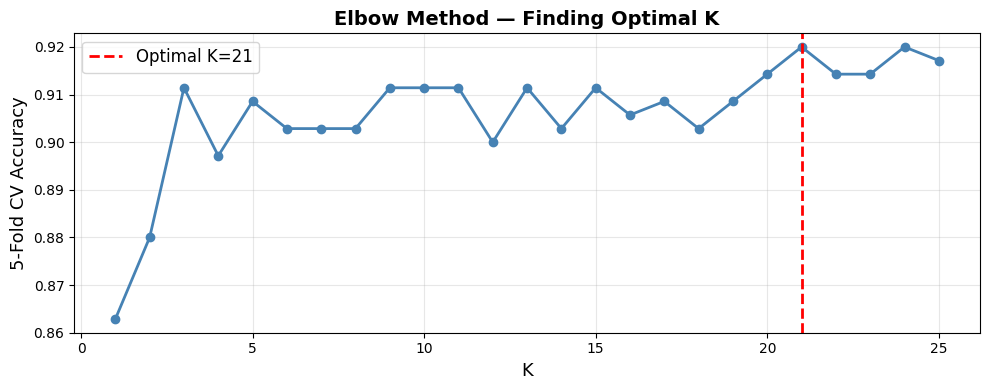

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Generate Dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {np.unique(y)}  Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Feature Scaling — CRITICAL for KNN
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 4. Find Optimal K via Cross-Validation
k_range   = range(1, 26)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
             X_train_s, y_train, cv=5, scoring='accuracy').mean()
             for k in k_range]

optimal_k = list(k_range)[np.argmax(cv_scores)]
print(f"\nOptimal K = {optimal_k}  |  Best CV Accuracy = {max(cv_scores):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(k_range, cv_scores, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal K={optimal_k}')
plt.xlabel('K', fontsize=13); plt.ylabel('5-Fold CV Accuracy', fontsize=13)
plt.title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.legend(fontsize=12); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Test Accuracy: 0.9133

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        75
           1       0.94      0.88      0.91        75

    accuracy                           0.91       150
   macro avg       0.92      0.91      0.91       150
weighted avg       0.92      0.91      0.91       150



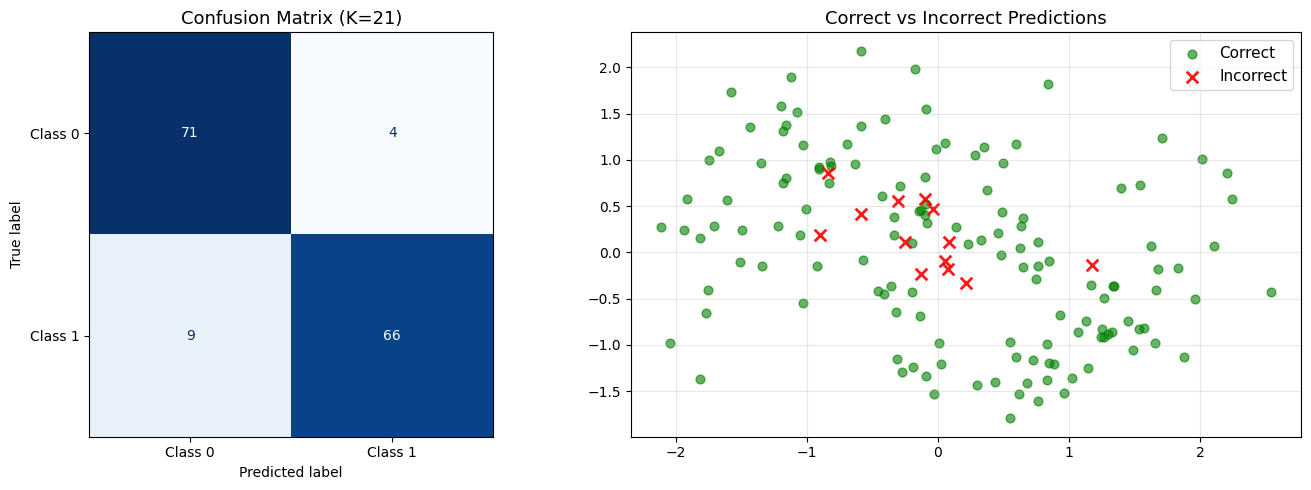

In [7]:
# 5. Train Final Model with Optimal K
knn_final = KNeighborsClassifier(
    n_neighbors=optimal_k,
    metric='minkowski',  # default
    p=2,                 # Euclidean
    weights='uniform'    # all neighbors equal weight
)
knn_final.fit(X_train_s, y_train)

# 6. Evaluate
y_pred  = knn_final.predict(X_test_s)
y_proba = knn_final.predict_proba(X_test_s)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix + Predictions Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0','Class 1'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (K={optimal_k})', fontsize=13)

correct = (y_pred == y_test)
axes[1].scatter(X_test_s[correct,0],  X_test_s[correct,1],
                c='green', alpha=0.6, s=40, label='Correct')
axes[1].scatter(X_test_s[~correct,0], X_test_s[~correct,1],
                c='red',   alpha=0.9, s=70, marker='x', linewidths=2, label='Incorrect')
axes[1].set_title('Correct vs Incorrect Predictions', fontsize=13)
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 10. Visualizing Decision Boundaries

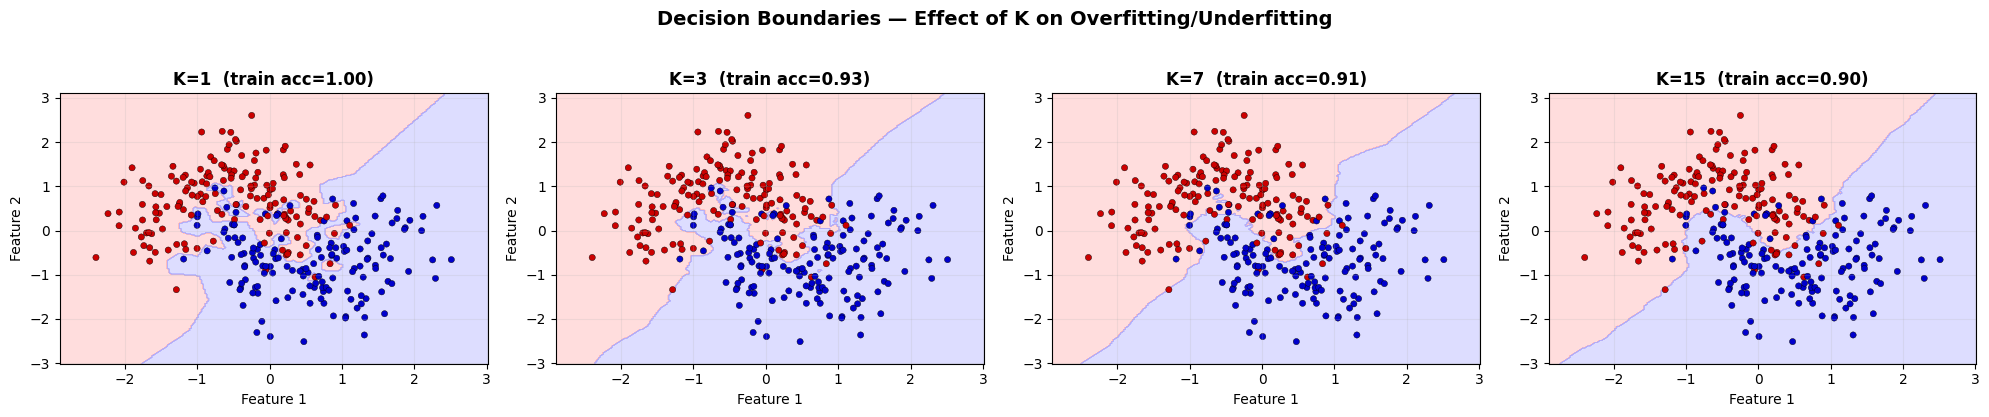

K=1  → Overfitted: perfectly memorizes training noise
K=3  → Smoother, captures non-linear structure
K=7  → Good generalization
K=15 → Over-smoothed, losing fine detail


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_s  = StandardScaler().fit_transform(X)

k_values = [1, 3, 7, 15]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

bg_cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])
pt_cmap = ListedColormap(['#CC0000', '#0000CC'])

xx, yy = np.meshgrid(
    np.linspace(X_s[:,0].min()-0.5, X_s[:,0].max()+0.5, 250),
    np.linspace(X_s[:,1].min()-0.5, X_s[:,1].max()+0.5, 250)
)

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_s, y)
    Z   = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=bg_cmap)
    ax.scatter(X_s[:,0], X_s[:,1], c=y, cmap=pt_cmap, s=20,
               edgecolors='k', linewidths=0.3)
    ax.set_title(f'K={k}  (train acc={knn.score(X_s, y):.2f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.grid(alpha=0.2)

fig.suptitle('Decision Boundaries — Effect of K on Overfitting/Underfitting',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print("K=1  → Overfitted: perfectly memorizes training noise")
print("K=3  → Smoother, captures non-linear structure")
print("K=7  → Good generalization")
print("K=15 → Over-smoothed, losing fine detail")

---
## 11. KNN for Regression

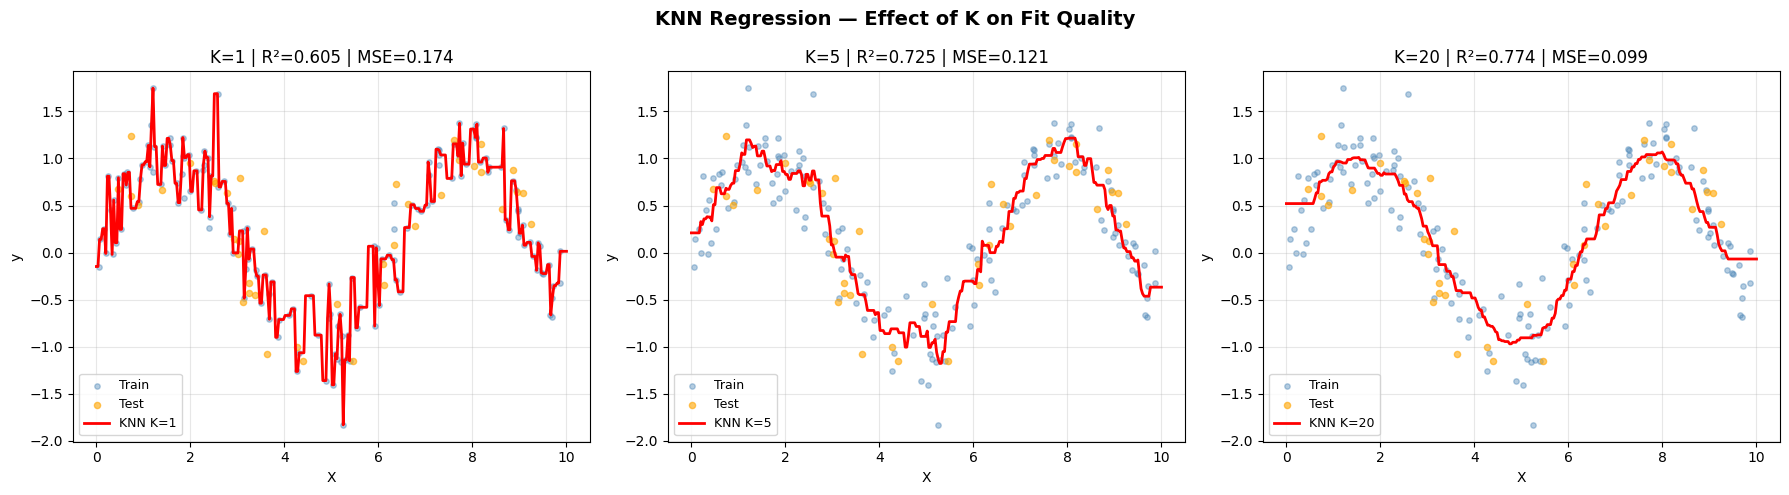

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X = np.sort(np.random.uniform(0, 10, 200)).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, 200)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

k_vals = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_line   = np.linspace(0, 10, 300).reshape(-1, 1)
X_line_s = scaler.transform(X_line)

for ax, k in zip(axes, k_vals):
    model  = KNeighborsRegressor(n_neighbors=k).fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2     = r2_score(y_test, y_pred)
    mse    = mean_squared_error(y_test, y_pred)

    ax.scatter(X_train, y_train, alpha=0.4, s=15, color='steelblue', label='Train')
    ax.scatter(X_test,  y_test,  alpha=0.6, s=20, color='orange',    label='Test')
    ax.plot(X_line, model.predict(X_line_s), color='red', linewidth=2, label=f'KNN K={k}')
    ax.set_title(f'K={k} | R²={r2:.3f} | MSE={mse:.3f}', fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlabel('X'); ax.set_ylabel('y')

fig.suptitle('KNN Regression — Effect of K on Fit Quality', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# a good model should have the red line passing close to orange dots, not just blue ones. Notice K=1 misses many orange dots despite fitting blue dots perfectly — that's the classic overfitting trap.

---
## 12. Summary

### KNN at a Glance

| Property | Detail |
|---|---|
| Full Name | K-Nearest Neighbors |
| Type | Supervised (Classification + Regression) |
| Learning | Lazy / Instance-based — no model built |
| Training Time | O(1) — just store data |
| Prediction Time | O(n × d) — expensive at query time |
| Key Hyperparameter | K (number of neighbors) |
| Default Distance | Euclidean (Minkowski p=2) |
| Feature Scaling | **Mandatory** (use StandardScaler) |
| Non-linear Boundaries | Yes |
| Multi-class Support | Yes (built-in) |
| High Dimensionality | Poor (curse of dimensionality) |

### When to Use KNN

| Situation | Recommendation |
|---|---|
| Small-medium dataset | ✅ Great choice |
| Quick baseline model | ✅ Go ahead |
| Non-linear boundaries | ✅ Works well |
| Large dataset (>100k) | ❌ Too slow |
| High-dimensional features | ❌ Distances lose meaning |
| Real-time prediction needed | ❌ Too slow |

### Sklearn Cheat Sheet
```python
from sklearn.neighbors import KNeighborsClassifier

KNeighborsClassifier(
    n_neighbors=5,          # K — number of neighbors
    metric='minkowski',     # distance metric
    p=2,                    # p=2 = Euclidean, p=1 = Manhattan
    weights='uniform',      # 'uniform' or 'distance'
    algorithm='auto'        # 'ball_tree', 'kd_tree', 'brute'
)
```

---
> **Reference:** [GeeksForGeeks — K-Nearest Neighbour Algorithm](https://www.geeksforgeeks.org/k-nearest-neighbours/)

---
## 13. KNN on Real SMS Spam/Ham Dataset

**Dataset:** UCI SMS Spam Collection — 5,574 real SMS messages  
**Labels:** `spam` (747 messages, 13.4%) vs `ham` (4,827 messages, 86.6%)

### Pipeline
```
Raw SMS text
    ↓  TF-IDF Vectorizer     (words → weighted numeric features)
    ↓  TruncatedSVD          (reduce 8000-dim → 100-dim for speed)
    ↓  StandardScaler        (normalize for distance calculations)
    ↓  KNN Classifier        (find K nearest messages by TF-IDF similarity)
    ↓  Prediction: spam / ham
```

> **Why TF-IDF?** Raw word counts make common words like "the", "is" dominate.  
> TF-IDF down-weights frequent words and up-weights rare/informative ones.

> **Why SVD?** KNN suffers from curse of dimensionality in 8000-dim space.  
> Reducing to 100 dimensions keeps the structure while making distances meaningful.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# ─── 1. Load Dataset ──────────────────────────────────────────────────────────
DATA_PATH = 'SMSSpamCollection'   # tab-separated, no header

df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=['label', 'message'])

print("=== SMS Spam Collection Dataset ===")
print(f"Total messages : {len(df)}")
print(f"Spam messages  : {(df.label=='spam').sum()}  ({(df.label=='spam').mean()*100:.1f}%)")
print(f"Ham  messages  : {(df.label=='ham').sum()}   ({(df.label=='ham').mean()*100:.1f}%)")
print(f"\nSample messages:")
print(df.sample(4, random_state=42)[['label','message']].to_string(index=False))

# ─── 2. Encode Labels ─────────────────────────────────────────────────────────
# spam → 1,  ham → 0
le = LabelEncoder()
y  = le.fit_transform(df['label'])   # ham=0, spam=1

# ─── 3. TF-IDF Vectorization ──────────────────────────────────────────────────
# max_features=8000: keep 8000 most common words
# stop_words: remove 'the', 'is', 'a', etc.
# ngram_range=(1,2): use single words AND word pairs (bigrams)
tfidf = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['message'])

print(f"\nTF-IDF matrix shape: {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]} messages × {X_tfidf.shape[1]} features (words+bigrams)")

# ─── 4. Dimensionality Reduction (SVD) ────────────────────────────────────────
# KNN in 8000-dim space = curse of dimensionality
# SVD reduces to 100 most informative dimensions
svd       = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f"\nSVD: 8000-dim → 100-dim")
print(f"Explained variance retained: {explained*100:.1f}%")

# ─── 5. Scale Features ────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_reduced)

# ─── 6. Train-Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

=== SMS Spam Collection Dataset ===
Total messages : 5572
Spam messages  : 747  (13.4%)
Ham  messages  : 4825   (86.6%)

Sample messages:
label                                                                                                                                             message
  ham Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u get 3 u r cute:) 6 u r luvd:* 9 u r so lucky;) None? People hate u:
  ham                                And also I've sorta blown him off a couple times recently so id rather not text him out of the blue looking for weed
  ham                                              Mmm thats better now i got a roast down me! id b better if i had a few drinks down me 2! Good indian?
  ham                                                                                                       Mm have some kanji dont eat anything heavy ok

TF-IDF matrix shape: (5572, 8000)
  → 5572 messages × 8000 features (words+bigrams)

SVD: 8

### 📌 What the above code did

**Step 1 — Loaded the dataset**
- Read `SMSSpamCollection` file: 5,572 real SMS messages with tab-separated `label` and `message` columns
- Dataset is **imbalanced**: 87% ham, only 13% spam

**Step 2 — Encoded labels**
- Converted text labels to numbers: `ham → 0`, `spam → 1`
- KNN needs numbers to compute distances, not text

**Step 3 — TF-IDF Vectorization**
- Converted every SMS message into a row of numbers (one number per word/bigram)
- Each number = how important that word is in that message vs all messages
- `max_features=8000` → kept top 8000 words+bigrams only
- `stop_words='english'` → removed useless words like "the", "is", "a"
- `ngram_range=(1,2)` → captured both single words ("free") AND word pairs ("free prize")
- Result: shape **(5572 messages × 8000 features)**

**Step 4 — TruncatedSVD (Dimensionality Reduction)**
- 8000 dimensions is too many for KNN — all points become equally far apart (curse of dimensionality)
- SVD compressed 8000 → **100 most informative "topic" dimensions**
- 22.4% of variance retained — enough structure to find similar messages

**Step 5 — StandardScaler**
- After SVD, some dimensions have larger values than others
- Scaler made all 100 dimensions have **mean=0, std=1** so no dimension dominates distance

**Step 6 — Train/Test Split**
- `stratify=y` ensures both train and test have the same 87%/13% ham/spam ratio
- Train: 4457 messages | Test: 1115 messages

Optimal K = 4  |  Best CV F1 = 0.8979


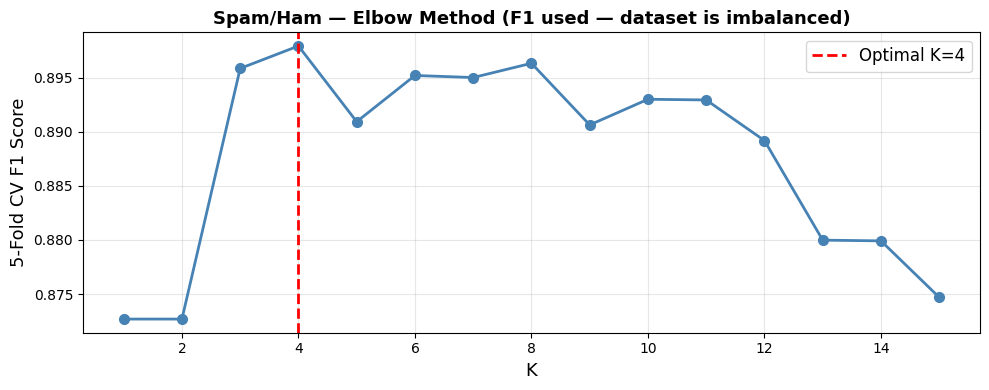


Test Accuracy : 0.9659

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.92      0.81      0.86       149

    accuracy                           0.97      1115
   macro avg       0.95      0.90      0.92      1115
weighted avg       0.97      0.97      0.96      1115



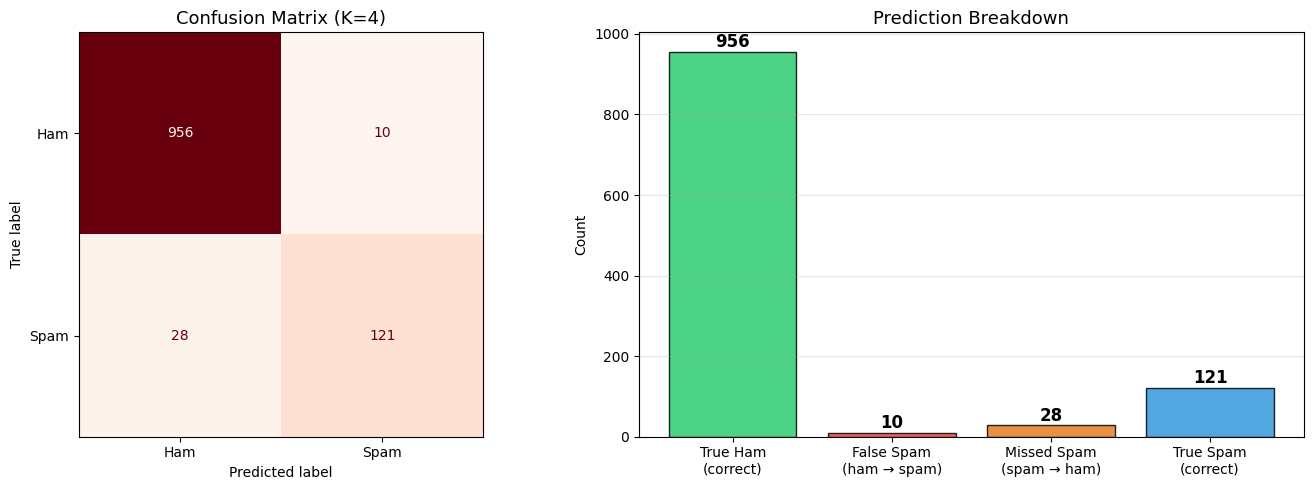


Key Metrics:
  True  Ham  (correctly identified ham)  : 956
  False Spam (ham misclassified as spam)  : 10  ← annoying for user
  Missed Spam (spam slipped through)      : 28  ← dangerous!
  True  Spam (correctly caught spam)      : 121


In [13]:
# ─── 7. Find Optimal K ────────────────────────────────────────────────────────
k_range   = range(1, 16)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k, weights='distance'),
             X_train, y_train, cv=5, scoring='f1').mean()
             for k in k_range]

optimal_k = list(k_range)[np.argmax(cv_scores)]
print(f"Optimal K = {optimal_k}  |  Best CV F1 = {max(cv_scores):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(k_range, cv_scores, marker='o', linewidth=2, markersize=7, color='steelblue')
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal K={optimal_k}')
plt.xlabel('K', fontsize=13); plt.ylabel('5-Fold CV F1 Score', fontsize=13)
plt.title('Spam/Ham — Elbow Method (F1 used — dataset is imbalanced)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=12); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ─── 8. Train Final KNN ───────────────────────────────────────────────────────
# weights='distance': closer neighbors vote more — helps with imbalanced data
knn = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance', metric='euclidean')
knn.fit(X_train, y_train)

# ─── 9. Evaluate ──────────────────────────────────────────────────────────────
y_pred = knn.predict(X_test)

print(f"\nTest Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# ─── 10. Confusion Matrix ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title(f'Confusion Matrix (K={optimal_k})', fontsize=13)

# What errors look like
tn, fp, fn, tp = cm.ravel()
categories = ['True Ham\n(correct)', 'False Spam\n(ham → spam)', 
              'Missed Spam\n(spam → ham)', 'True Spam\n(correct)']
values     = [tn, fp, fn, tp]
bar_colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']
bars = axes[1].bar(categories, values, color=bar_colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Prediction Breakdown', fontsize=13)
axes[1].set_ylabel('Count'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nKey Metrics:")
print(f"  True  Ham  (correctly identified ham)  : {tn}")
print(f"  False Spam (ham misclassified as spam)  : {fp}  ← annoying for user")
print(f"  Missed Spam (spam slipped through)      : {fn}  ← dangerous!")
print(f"  True  Spam (correctly caught spam)      : {tp}")

### What the above code did

**Step 7 — Found Optimal K using F1, not Accuracy**
- Why F1? The dataset is **imbalanced** (87% ham, 13% spam). A dumb model that predicts "ham" every time would get 87% accuracy — that number is misleading. F1 score penalizes both missing spam (false negatives) and wrongly flagging ham (false positives), so it actually reflects useful performance.
- Tested K values 1–15 with 5-fold cross-validation, picked the K with the highest F1.

**Step 8 — Trained with `weights='distance'`**
- `weights='uniform'` (default): every neighbor gets 1 vote regardless of distance.
- `weights='distance'`: **closer neighbors vote more strongly**, farther neighbors vote less.
- On imbalanced data this matters — a spam message surrounded by 4 close ham and 1 distant spam might still be correctly called spam because the nearby ham's distances average out.

**Steps 9–10 — Evaluated and Plotted the Confusion Matrix**

The confusion matrix has 4 boxes:

| Box | Meaning | Why it matters |
|---|---|---|
| **True Ham (TN)** | Correctly delivered ham | Good — no false alarms |
| **False Spam (FP)** | Ham wrongly marked spam | Annoying — real messages blocked |
| **Missed Spam (FN)** | Spam that slipped through | Dangerous — filter failed |
| **True Spam (TP)** | Spam correctly caught | Goal — what we want high |

> The bar chart shows the same four numbers visually so you can instantly see which error type dominates.

### What the above code did

**Steps 11–12 — Predicted new messages and showed the reasoning**

**Why `.transform()` and NOT `.fit_transform()`**
- `fit_transform()` would re-learn vocabulary/SVD/scaling from scratch on the 8 new messages — that's wrong. The model was trained on 4,457 messages; it learned what "FREE", "winner", "prize" mean in context.
- `.transform()` applies the **same rules learned during training** to new data. This is the only correct way to use a model in production.

**Reading the spam % / ham % probabilities**
- `predict_proba()` returns the **distance-weighted vote share** among the K nearest neighbors.
- Example: `ham=46% spam=54%` → more than half the neighbor-weight voted spam → classified SPAM.
- `ham=100% spam=0%` → all neighbors were ham with high confidence.
- The closer to 50/50, the less confident the model is — borderline messages are harder to classify.

**What the nearest-neighbor output shows**
- `kneighbors()` returned the 5 actual training messages closest to your new message in the 100-dim SVD space.
- It shows **why** KNN made that decision — it's not a black box. You can read the neighbor messages and understand the reasoning.
- Distance values: **smaller = more similar**. A neighbor at `dist=2.5` is much more similar than one at `dist=3.7`.
- Note: even if a new spam message lands near ham neighbors (because its wording is unusual), the **distance-weighting** gives the closest neighbor the most influence.

**The full pipeline at prediction time:**
```
new message (text)
    → tfidf.transform()    ← apply same vocabulary from training
    → svd.transform()      ← apply same 100 topics from training
    → scaler.transform()   ← apply same mean/std from training
    → knn.predict()        ← find K nearest, weighted vote
```

In [14]:
# ─── 11. Predict New Messages ─────────────────────────────────────────────────
new_messages = [
    "FREE entry in 2 a wkly comp to win FA Cup final tkts 21st May",
    "Hey, are we still meeting for lunch tomorrow at noon?",
    "WINNER!! You have been selected to receive a cash prize of $1000",
    "Can you please call me back when you get a chance?",
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Don't forget the project deadline is this Friday",
    "URGENT: Your account has been compromised. Verify now to avoid suspension",
    "Thanks for coming to the party last night, it was great seeing you"
]

# Transform using the SAME tfidf + svd + scaler fitted on training data
X_new_tfidf   = tfidf.transform(new_messages)
X_new_reduced = svd.transform(X_new_tfidf)
X_new_scaled  = scaler.transform(X_new_reduced)

preds  = knn.predict(X_new_scaled)
probas = knn.predict_proba(X_new_scaled)

print("=== KNN Predictions on New SMS Messages ===\n")
for msg, pred, proba in zip(new_messages, preds, probas):
    label    = 'SPAM' if pred == 1 else 'HAM'
    icon     = '🚨' if pred == 1 else '✅'
    ham_pct  = proba[0] * 100
    spam_pct = proba[1] * 100
    short    = msg[:55] + '...' if len(msg) > 55 else msg
    print(f"{icon} [{label}]  ham={ham_pct:.0f}%  spam={spam_pct:.0f}%")
    print(f"   '{short}'\n")

# ─── 12. KNN Finds K Nearest Training Messages ────────────────────────────────
# Show WHY KNN made its decision for 1 example
print("=" * 60)
print("HOW KNN decided for message 1 (spam):")
print(f"  '{new_messages[0][:60]}...'")
print("=" * 60)

distances_raw, indices = knn.kneighbors(X_new_scaled[[0]], n_neighbors=5)
print(f"\nThe {knn.n_neighbors} nearest training messages were:\n")
for rank, (idx, dist) in enumerate(zip(indices[0], distances_raw[0]), 1):
    neighbor_label = 'spam' if y[idx] == 1 else 'ham'
    neighbor_msg   = df['message'].iloc[idx]
    short          = neighbor_msg[:70] + '...' if len(neighbor_msg) > 70 else neighbor_msg
    print(f"  Rank {rank} | dist={dist:.3f} | [{neighbor_label.upper()}]")
    print(f"    '{short}'\n")

=== KNN Predictions on New SMS Messages ===

🚨 [SPAM]  ham=46%  spam=54%
   'FREE entry in 2 a wkly comp to win FA Cup final tkts 21...'

✅ [HAM]  ham=100%  spam=0%
   'Hey, are we still meeting for lunch tomorrow at noon?'

🚨 [SPAM]  ham=0%  spam=100%
   'WINNER!! You have been selected to receive a cash prize...'

✅ [HAM]  ham=100%  spam=0%
   'Can you please call me back when you get a chance?'

🚨 [SPAM]  ham=24%  spam=76%
   'Congratulations! You've won a FREE iPhone. Click here t...'

✅ [HAM]  ham=100%  spam=0%
   'Don't forget the project deadline is this Friday'

✅ [HAM]  ham=100%  spam=0%
   'URGENT: Your account has been compromised. Verify now t...'

✅ [HAM]  ham=76%  spam=24%
   'Thanks for coming to the party last night, it was great...'

HOW KNN decided for message 1 (spam):
  'FREE entry in 2 a wkly comp to win FA Cup final tkts 21st Ma...'

The 4 nearest training messages were:

  Rank 1 | dist=2.585 | [HAM]
    'So is there anything specific I should be doing with regar

A very good reference 
https://github.com/krishnaik06/K-Nearest-Neighour/blob/master/K%20Nearest%20Neighbors%20with%20Python.ipynb